<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/%5B05.1%5D%20-%20WS%20PT/EDA_WS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ Guía Completa de EDA — Paso a Paso
## Todas las casuísticas con el dataset Superstore

> **Cómo usar esta guía:** Cada sección muestra (1) el código que ejecutas siempre, (2) cómo interpretar el resultado, y (3) qué hacer según lo que encuentres. El dataset Superstore es un caso "limpio", pero aquí verás también qué harías si los datos estuvieran sucios.

---

### Índice
1. Carga de datos
2. Primera inspección general
3. Tipos de variables
4. Valores nulos
5. Duplicados
6. Outliers
7. Distribuciones (variables numéricas)
8. Variables categóricas
9. Correlaciones
10. Análisis del target
11. Feature Engineering
12. Encoding
13. Escalado
14. Checklist final

In [ ]:
# ============================================================
# IMPORTS — ejecutar siempre al inicio
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PASO 1 — Carga de datos

**¿Qué hacemos?** Leer el fichero y ver las primeras filas para saber con qué estamos trabajando.

**Opciones de carga más habituales:**
```python
# CSV normal
df = pd.read_csv('archivo.csv')

# CSV con encoding especial (tildes, ñ, etc.)
df = pd.read_csv('archivo.csv', encoding='latin1')
df = pd.read_csv('archivo.csv', encoding='utf-8')

# CSV con separador diferente (punto y coma)
df = pd.read_csv('archivo.csv', sep=';')

# Excel
df = pd.read_excel('archivo.xlsx', sheet_name='Hoja1')

# Desde URL (GitHub, etc.)
df = pd.read_csv('https://url-del-dataset.csv', encoding='latin1')
```

In [ ]:
URL = 'https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv'
df = pd.read_csv(URL, encoding='latin1')

print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

✅ Dataset cargado: 9,994 filas × 21 columnas


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


---
## PASO 2 — Primera inspección general

**¿Qué buscamos?** El tamaño del dataset, qué columnas hay y un resumen estadístico rápido.

**Preguntas que respondemos aquí:**
- ¿Cuántas filas y columnas tiene?
- ¿Cuáles son los rangos de las variables numéricas?
- ¿Hay algo que llame la atención a primera vista?

In [ ]:
# Tamaño
print(f'Filas    : {df.shape[0]:,}')
print(f'Columnas : {df.shape[1]}')
print()

# Estadísticas descriptivas de variables numéricas
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().round(2)

Filas    : 9,994
Columnas : 21

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [ ]:
# También es útil ver las últimas filas (por si hay totales o filas raras al final)
df.tail(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


---
## PASO 3 — Tipos de variables

**¿Qué buscamos?** Verificar que cada columna tiene el tipo correcto.

**Tipos principales en pandas:**
| Tipo pandas | Significa | Ejemplo |
|---|---|---|
| `int64` | Número entero | Quantity, Row ID |
| `float64` | Número decimal | Sales, Profit |
| `object` | Texto / categoría | Segment, City |
| `datetime64` | Fecha | Order Date |
| `bool` | Verdadero/Falso | is_profitable |

**⚠️ Errores comunes a detectar:**
- Una fecha que aparece como `object` → hay que convertirla
- Un número que aparece como `object` → suele tener comas, puntos o caracteres raros
- Un código postal numérico que debería ser texto (`"01001"` vs `1001`)

In [ ]:
print('=== TIPOS DE VARIABLES ===')
print(df.dtypes)
print()

# Resumen por tipo
print('=== RESUMEN POR TIPO ===')
print(df.dtypes.value_counts())

=== TIPOS DE VARIABLES ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== RESUMEN POR TIPO ===
object     15
int64       3
float64     3
Name: count, dtype: int64


In [ ]:
# -------------------------------------------------------
# CORRECCIONES DE TIPO — aplicar según lo que encuentres
# -------------------------------------------------------

# CASO 1: Convertir fechas (Order Date aparece como object → la convertimos)
# El dataset usa formato americano M/D/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')
print('✅ Fechas convertidas:', df['Order Date'].dtype)

# CASO 2: Código postal como string (para no perder el cero inicial)
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)
print('✅ Postal Code como string:', df['Postal Code'].dtype)

# CASO 3 (si lo necesitas): Número que viene como texto con comas
# df['columna'] = df['columna'].str.replace(',', '').astype(float)

# CASO 4 (si lo necesitas): Convertir columna a categoría
# df['Segment'] = df['Segment'].astype('category')

print()
print('Tipos actualizados:')
print(df[['Order Date', 'Ship Date', 'Postal Code']].dtypes)

✅ Fechas convertidas: datetime64[ns]
✅ Postal Code como string: object

Tipos actualizados:
Order Date     datetime64[ns]
Ship Date      datetime64[ns]
Postal Code            object
dtype: object


---
## PASO 4 — Valores nulos

**¿Qué buscamos?** Columnas con datos faltantes.

**Estrategias según el caso:**

| Situación | Qué hacer |
|---|---|
| 0 nulos | No hacer nada ✅ |
| Nulos en columna sin valor predictivo | Eliminar la columna |
| Pocos nulos (<5%) en numérica | Imputar con media o mediana |
| Pocos nulos (<5%) en categórica | Imputar con moda o `'Desconocido'` |
| Muchos nulos (>30%) | Valorar eliminar la columna entera |
| Muchos nulos en filas | Valorar eliminar esas filas con `dropna()` |

In [ ]:
# Conteo y porcentaje de nulos por columna
nulos = df.isnull().sum()
pct   = (df.isnull().mean() * 100).round(2)

resumen_nulos = pd.DataFrame({'n_nulos': nulos, 'pct_nulos': pct})
resumen_nulos = resumen_nulos[resumen_nulos['n_nulos'] > 0].sort_values('pct_nulos', ascending=False)

if len(resumen_nulos) == 0:
    print('✅ No hay valores nulos en ninguna columna.')
else:
    print(f'⚠️ Se encontraron nulos en {len(resumen_nulos)} columnas:')
    print(resumen_nulos)

✅ No hay valores nulos en ninguna columna.


In [ ]:
# -------------------------------------------------------
# TRATAMIENTO DE NULOS — descomenta según tu caso
# -------------------------------------------------------

# OPCIÓN A: Eliminar FILAS con nulos (si son pocas y aleatorias)
# df = df.dropna()
# print('Filas tras dropna:', len(df))

# OPCIÓN B: Eliminar COLUMNAS con muchos nulos (>30%)
# umbral = 0.30
# df = df.loc[:, df.isnull().mean() < umbral]

# OPCIÓN C: Imputar numérica con la MEDIANA (más robusta que la media ante outliers)
# df['columna_numerica'] = df['columna_numerica'].fillna(df['columna_numerica'].median())

# OPCIÓN D: Imputar numérica con la MEDIA
# df['columna_numerica'] = df['columna_numerica'].fillna(df['columna_numerica'].mean())

# OPCIÓN E: Imputar categórica con la MODA (valor más frecuente)
# df['columna_cat'] = df['columna_cat'].fillna(df['columna_cat'].mode()[0])

# OPCIÓN F: Imputar categórica con un valor fijo
# df['columna_cat'] = df['columna_cat'].fillna('Desconocido')

# En Superstore no hay nulos, así que no hacemos nada.
print('✅ Sin nulos: no se necesita imputación.')

✅ Sin nulos: no se necesita imputación.


---
## PASO 5 — Duplicados

**¿Qué buscamos?** Filas repetidas que podrían sesgar el modelo.

**Tres niveles de duplicados:**
1. **Fila 100% idéntica** → la más obvia, siempre eliminar
2. **Mismo ID de pedido + producto** → puede ser un error de carga
3. **Mismo cliente + fecha + importe** → duplicado de negocio

**¿Cuándo NO eliminar?** Si el dataset tiene pedidos repetidos legítimos (un cliente compra el mismo producto dos veces el mismo día → son dos filas válidas).

In [ ]:
# Nivel 1: filas 100% idénticas
dup_total = df.duplicated().sum()
print(f'Filas 100% duplicadas          : {dup_total}')

# Nivel 2: mismo Order ID + Product ID
dup_pedido = df.duplicated(subset=['Order ID', 'Product ID']).sum()
print(f'Duplicados Order ID + Product  : {dup_pedido}')

# Nivel 3: mismo Row ID (debe ser clave única)
dup_rowid = df.duplicated(subset=['Row ID']).sum()
print(f'Duplicados Row ID (PK)         : {dup_rowid}')

print()
if dup_total == 0:
    print('✅ No hay duplicados.')
else:
    print('⚠️ Hay duplicados. Ver opciones abajo.')

Filas 100% duplicadas          : 0
Duplicados Order ID + Product  : 8
Duplicados Row ID (PK)         : 0

✅ No hay duplicados.


In [ ]:
# -------------------------------------------------------
# TRATAMIENTO DE DUPLICADOS — descomenta según tu caso
# -------------------------------------------------------

# OPCIÓN A: Eliminar filas 100% duplicadas (la más común)
# df = df.drop_duplicates()
# print('Filas tras eliminar duplicados:', len(df))

# OPCIÓN B: Eliminar por combinación de columnas específicas,
# quedándose con la primera ocurrencia
# df = df.drop_duplicates(subset=['Order ID', 'Product ID'], keep='first')

# OPCIÓN C: Ver los duplicados antes de eliminar
# duplicados = df[df.duplicated(keep=False)]
# print(duplicados.head(10))

print('✅ Sin duplicados: no se necesita limpieza.')

✅ Sin duplicados: no se necesita limpieza.


---
## PASO 6 — Outliers

**¿Qué buscamos?** Valores extremos que podrían distorsionar el modelo.

**Método IQR (el más robusto):**
- Límite inferior = Q1 − 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR
- Todo lo que quede fuera de esos límites es un outlier

**¿Siempre hay que eliminar outliers?** No. Depende del contexto:

| Caso | Qué hacer |
|---|---|
| Error de introducción de datos (ej. edad = 999) | Eliminar o imputar |
| Valor extremo legítimo (ej. pedido de 22.000$) | **Conservar** — es información real |
| Outlier en el **target** de regresión | Conservar — el modelo debe aprenderlos |
| Outlier que distorsiona el modelo lineal | Valorar transformación logarítmica |

In [ ]:
# Función para detectar outliers con el método IQR
def resumen_outliers(df, columnas):
    resultados = []
    for col in columnas:
        serie = df[col].dropna()
        q1, q3 = serie.quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        n_out   = ((serie < lim_inf) | (serie > lim_sup)).sum()
        resultados.append({
            'columna'   : col,
            'min'       : round(serie.min(), 2),
            'max'       : round(serie.max(), 2),
            'lim_inf_IQR': round(lim_inf, 2),
            'lim_sup_IQR': round(lim_sup, 2),
            'n_outliers' : n_out,
            'pct_outliers': round(n_out / len(serie) * 100, 2)
        })
    return pd.DataFrame(resultados).set_index('columna')

cols_numericas = ['Sales', 'Quantity', 'Discount', 'Profit']
resumen_outliers(df, cols_numericas)

,min,max,lim_inf_IQR,lim_sup_IQR,n_outliers,pct_outliers
columna,,,,,,
Sales,0.44,22638.48,-271.71,498.93,1167,11.68
Quantity,1.00,14.00,-2.50,9.50,170,1.70
Discount,0.00,0.80,-0.30,0.50,856,8.57
Profit,-6599.98,8399.98,-39.72,70.82,1881,18.82


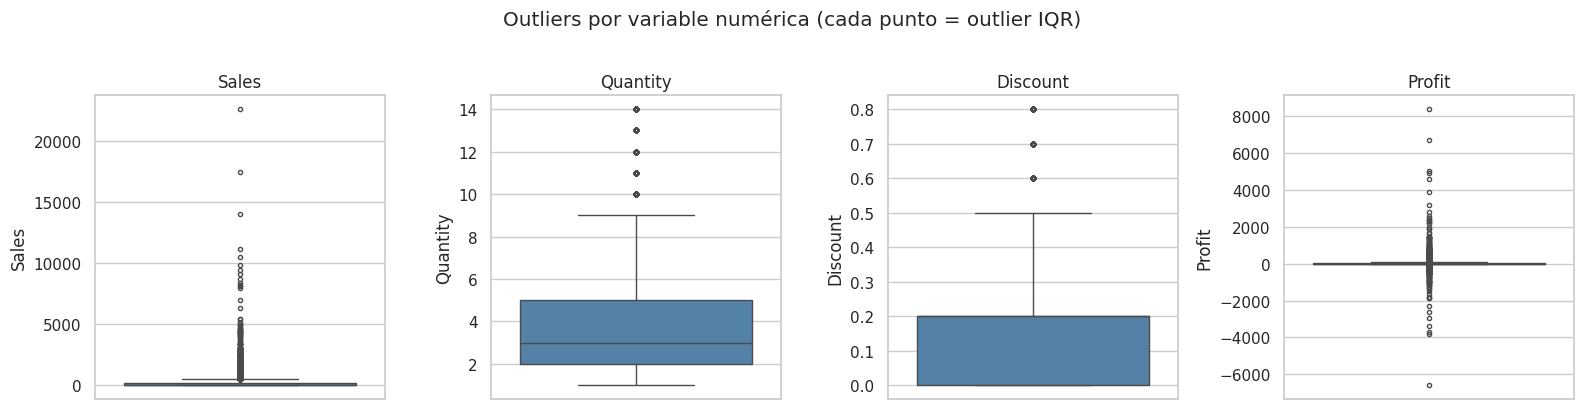


Top 3 pedidos con mayor PÉRDIDA:
             Category Sub-Category     Sales  Discount     Profit
7772       Technology     Machines  4499.985       0.7 -6599.9780
683        Technology     Machines  7999.980       0.5 -3839.9904
9774  Office Supplies      Binders  2177.584       0.8 -3701.8928

Top 3 pedidos con mayor BENEFICIO:
        Category Sub-Category     Sales  Discount     Profit
6826  Technology      Copiers  17499.95       0.0  8399.9760
8153  Technology      Copiers  13999.96       0.0  6719.9808
4190  Technology      Copiers  10499.97       0.0  5039.9856


In [ ]:
# Visualización: boxplots para ver outliers gráficamente
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_numericas):
    sns.boxplot(y=df[col], ax=ax, color='steelblue', flierprops=dict(marker='o', markersize=3))
    ax.set_title(col)
plt.suptitle('Outliers por variable numérica (cada punto = outlier IQR)', y=1.02)
plt.tight_layout()
plt.show()

# Inspección manual: pedidos con pérdidas extremas
print('\nTop 3 pedidos con mayor PÉRDIDA:')
print(df.nsmallest(3, 'Profit')[['Category', 'Sub-Category', 'Sales', 'Discount', 'Profit']])

print('\nTop 3 pedidos con mayor BENEFICIO:')
print(df.nlargest(3, 'Profit')[['Category', 'Sub-Category', 'Sales', 'Discount', 'Profit']])

In [ ]:
# -------------------------------------------------------
# TRATAMIENTO DE OUTLIERS — descomenta según tu caso
# -------------------------------------------------------

# OPCIÓN A: Eliminar filas con outliers extremos
# q1, q3 = df['Profit'].quantile([0.25, 0.75])
# iqr = q3 - q1
# df = df[(df['Profit'] >= q1 - 3*iqr) & (df['Profit'] <= q3 + 3*iqr)]  # usa 3x para ser menos agresivo

# OPCIÓN B: Winsorización — recortar al percentil 1% y 99%
# from scipy.stats import mstats
# df['Sales_wins'] = mstats.winsorize(df['Sales'], limits=[0.01, 0.01])

# OPCIÓN C: Transformación logarítmica (reduce el impacto de outliers)
# df['log_Sales'] = np.log1p(df['Sales'])   # log1p = log(1 + x), funciona con 0

# OPCIÓN D (recomendada para Superstore): CONSERVAR los outliers
# Los pedidos de ventas altas son información real y valiosa.
# Los modelos de árboles (Random Forest, XGBoost) son robustos ante outliers.
print('✅ Outliers identificados pero conservados (valores legítimos de negocio).')

✅ Outliers identificados pero conservados (valores legítimos de negocio).


---
## PASO 7 — Distribuciones (variables numéricas)

**¿Qué buscamos?**
- ¿Tiene forma normal (campana de Gauss)?
- ¿Hay picos extraños o valores imposibles?

**Lo que suele aparecer en Superstore:**
- `Sales` y `Profit` → muy asimétricas (cola larga a la derecha)
- `Discount` → discreta, concentrada en valores fijos (0.0, 0.2, 0.3...)
- `Quantity` → discreta, valores entre 1 y 14

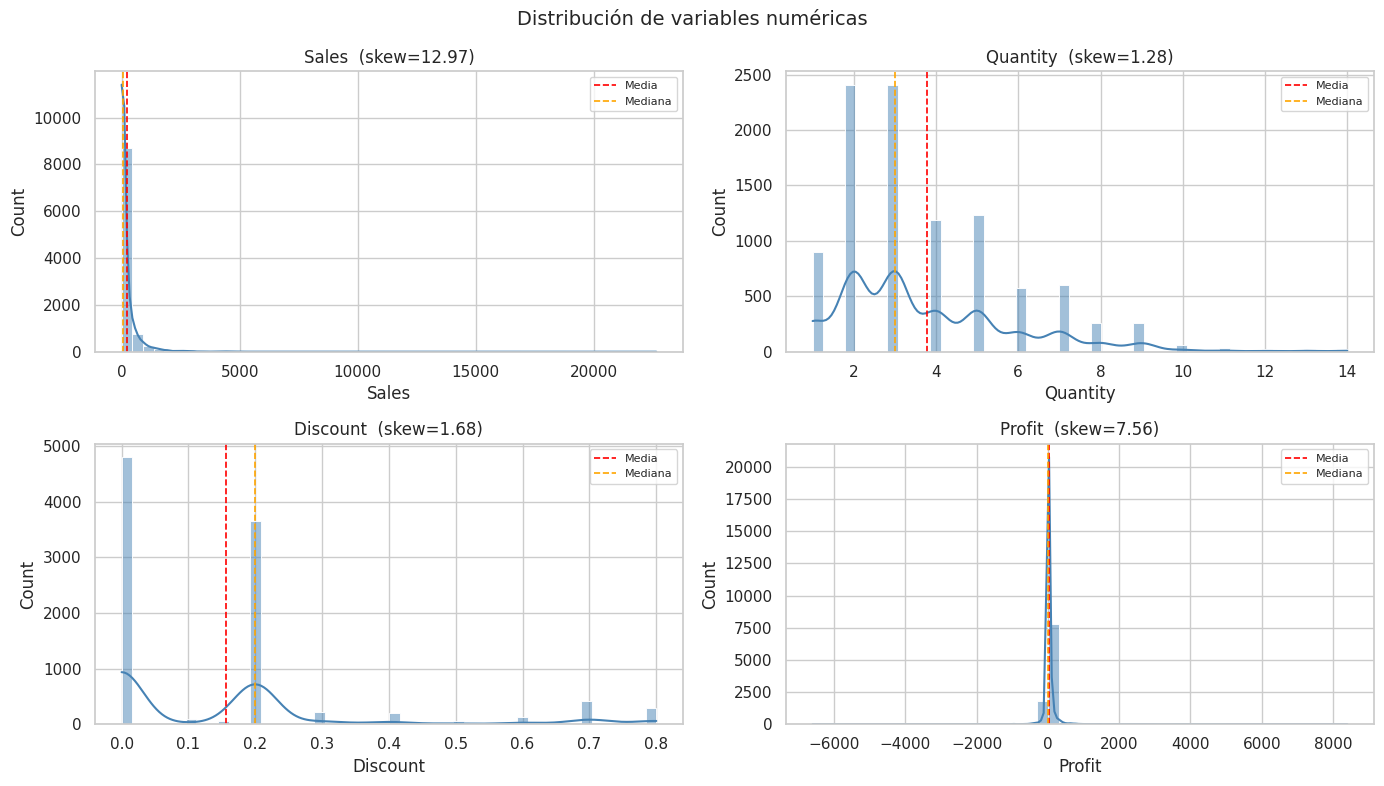


Asimetría (skewness) de cada variable:
  Sales       :  12.97 → asimétrica derecha (+)
  Quantity    :   1.28 → asimétrica derecha (+)
  Discount    :   1.68 → asimétrica derecha (+)
  Profit      :   7.56 → asimétrica derecha (+)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribución de variables numéricas', fontsize=14)

for ax, col in zip(axes.flatten(), cols_numericas):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=50)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.2, label='Media')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.2, label='Mediana')
    ax.set_title(f'{col}  (skew={df[col].skew():.2f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ¿Cómo leer el skew?
print('\nAsimetría (skewness) de cada variable:')
for col in cols_numericas:
    sk = df[col].skew()
    interpretacion = 'simétrica' if abs(sk) < 0.5 else ('asimétrica derecha (+)' if sk > 0 else 'asimétrica izquierda (-)')
    print(f'  {col:<12}: {sk:>6.2f} → {interpretacion}')

---
## PASO 8 — Variables categóricas

**¿Qué buscamos?**
- Cardinalidad: ¿cuántos valores únicos tiene cada categoría?
- Valores raros: categorías con muy pocos registros (pueden ser errores)
- Distribución: ¿están las clases equilibradas o hay una que domina?

**Regla general de cardinalidad:**
| Cardinalidad | Tratamiento |
|---|---|
| 2-15 valores | Label Encoding u One-Hot Encoding |
| 15-50 valores | Label Encoding o Target Encoding |
| >50 valores | Agrupar, eliminar, o usar técnicas avanzadas |

In [ ]:
# Cardinalidad de todas las variables categóricas
cols_cat = df.select_dtypes(include='object').columns.tolist()

print('=== CARDINALIDAD DE VARIABLES CATEGÓRICAS ===')
card_df = pd.DataFrame({
    'valores_unicos': [df[c].nunique() for c in cols_cat],
    'valor_mas_frecuente': [df[c].value_counts().index[0] for c in cols_cat],
    'frecuencia_max_%': [(df[c].value_counts().iloc[0] / len(df) * 100).round(1) for c in cols_cat]
}, index=cols_cat).sort_values('valores_unicos', ascending=False)

print(card_df)

=== CARDINALIDAD DE VARIABLES CATEGÓRICAS ===
               valores_unicos valor_mas_frecuente  frecuencia_max_%
Order ID                 5009      CA-2017-100111               0.1
Product ID               1862     OFF-PA-10001970               0.2
Product Name             1850     Staple envelope               0.5
Customer ID               793            WB-21850               0.4
Customer Name             793       William Brown               0.4
Postal Code               631               10035               2.6
City                      531       New York City               9.2
State                      49          California              20.0
Sub-Category               17             Binders              15.2
Ship Mode                   4      Standard Class              59.7
Region                      4                West              32.0
Segment                     3            Consumer              51.9
Category                    3     Office Supplies              60.3
Co

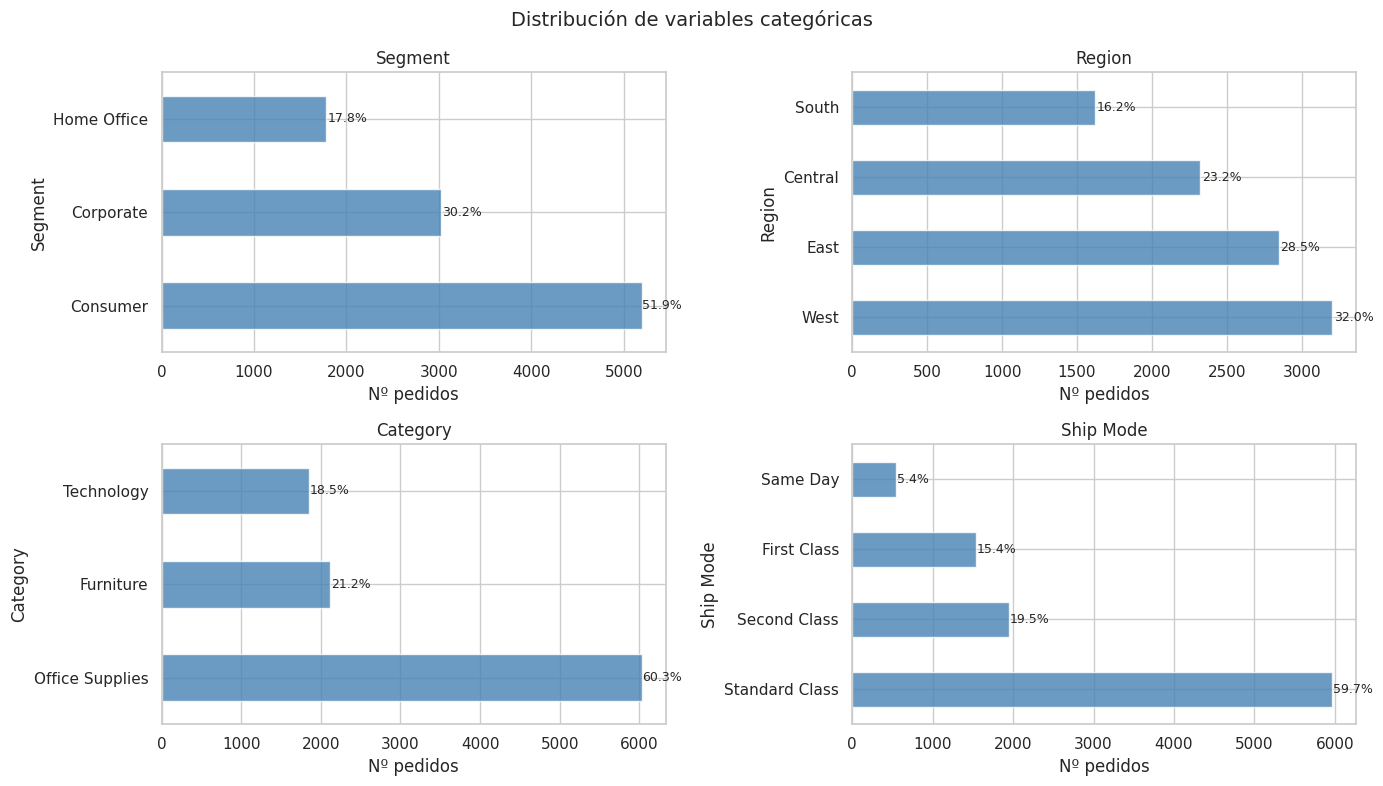


Sub-categorías con menos de 100 pedidos:
Sub-Category
Copiers    68
Name: count, dtype: int64


In [ ]:
# Visualización de las categóricas con baja cardinalidad
cols_baja_card = ['Segment', 'Region', 'Category', 'Ship Mode']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribución de variables categóricas', fontsize=14)

for ax, col in zip(axes.flatten(), cols_baja_card):
    conteos = df[col].value_counts()
    conteos.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('Nº pedidos')
    # Añadir etiquetas de porcentaje
    for i, v in enumerate(conteos.values):
        ax.text(v + 10, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ¿Hay categorías con muy pocos registros (posibles errores)?
print('\nSub-categorías con menos de 100 pedidos:')
raras = df['Sub-Category'].value_counts()
print(raras[raras < 100])

---
## PASO 9 — Correlaciones

**¿Qué buscamos?**
- Qué variables están relacionadas entre sí
- Qué variables se relacionan con el target (Profit)


**Cómo leer el heatmap:**
- **+1.0** → correlación positiva perfecta (suben juntas)
- **-1.0** → correlación negativa perfecta (una sube, la otra baja)
- **0.0** → no hay relación lineal
- Valores **> |0.7|** → correlación fuerte → posible multicolinealidad

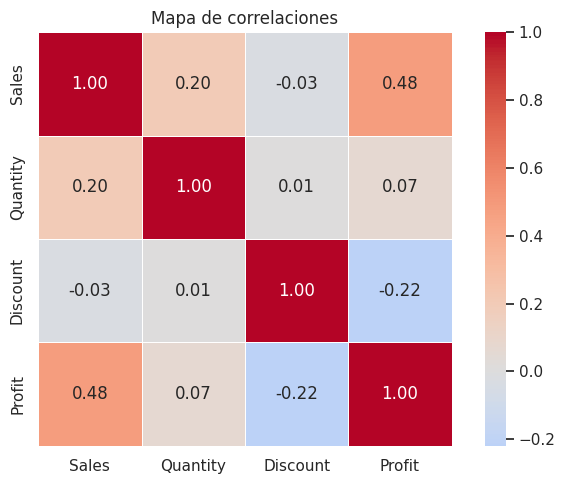


=== CORRELACIÓN CON EL TARGET (Profit) ===
Profit      1.000000
Sales       0.479064
Quantity    0.066253
Discount   -0.219487
Name: Profit, dtype: float64


In [ ]:
# Seleccionamos solo numéricas para la correlación
cols_corr = ['Sales', 'Quantity', 'Discount', 'Profit']
corr = df[cols_corr].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Mapa de correlaciones')
plt.tight_layout()
plt.show()

# Correlaciones con el target ordenadas
print('\n=== CORRELACIÓN CON EL TARGET (Profit) ===')
print(corr['Profit'].sort_values(ascending=False))

---
## PASO 10 — Análisis del target

**¿Qué buscamos?**
- Para **clasificación**: ¿están las clases equilibradas? El desbalanceo afecta al modelo.
- Para **regresión**: ¿cómo se distribuye el target? ¿Tiene muchos outliers?

**Desbalanceo de clases en clasificación:**
| Ratio mayoritaria/minoritaria | Severidad | Qué hacer |
|---|---|---|
| < 2:1 | Sin problema | Nada |
| 2:1 – 5:1 | Moderado | `class_weight='balanced'` |
| 5:1 – 10:1 | Alto | SMOTE o submuestreo |
| > 10:1 | Severo | Técnicas especializadas |

=== DISTRIBUCIÓN DEL TARGET (Clasificación) ===
  Rentables (1)    : 8,058  (80.6%)
  No rentables (0) : 1,936  (19.4%)
  Ratio            : 4.2:1


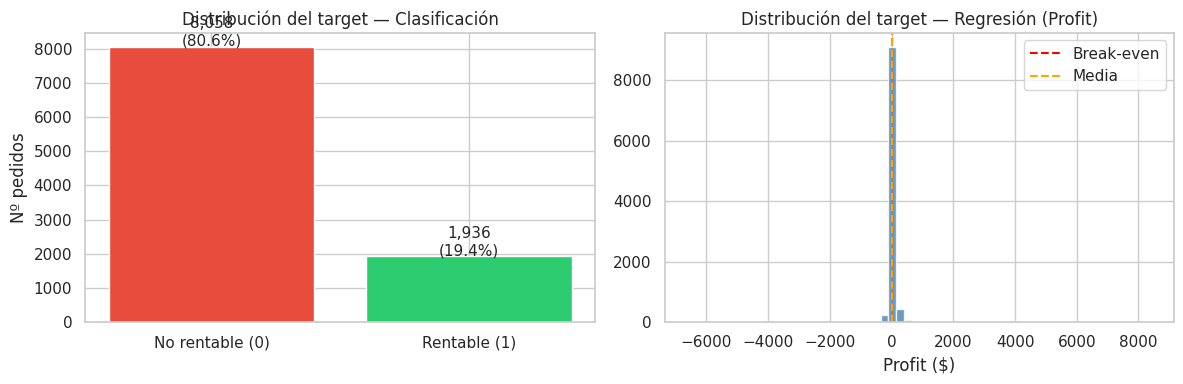

In [ ]:
# --- TARGET CLASIFICACIÓN: is_profitable ---
target_clf = (df['Profit'] > 0).astype(int)

conteo = target_clf.value_counts()
pct    = target_clf.value_counts(normalize=True).round(3) * 100

print('=== DISTRIBUCIÓN DEL TARGET (Clasificación) ===')
print(f'  Rentables (1)    : {conteo[1]:,}  ({pct[1]:.1f}%)')
print(f'  No rentables (0) : {conteo[0]:,}  ({pct[0]:.1f}%)')
print(f'  Ratio            : {conteo[1]/conteo[0]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras del target
colores_bar = ['#e74c3c', '#2ecc71']
axes[0].bar(['No rentable (0)', 'Rentable (1)'], conteo.values, color=colores_bar, edgecolor='white')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, f'{v:,}\n({pct.values[i]:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Distribución del target — Clasificación')
axes[0].set_ylabel('Nº pedidos')

# Distribución del target de regresión (Profit)
axes[1].hist(df['Profit'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[1].axvline(df['Profit'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Media')
axes[1].set_title('Distribución del target — Regresión (Profit)')
axes[1].set_xlabel('Profit ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

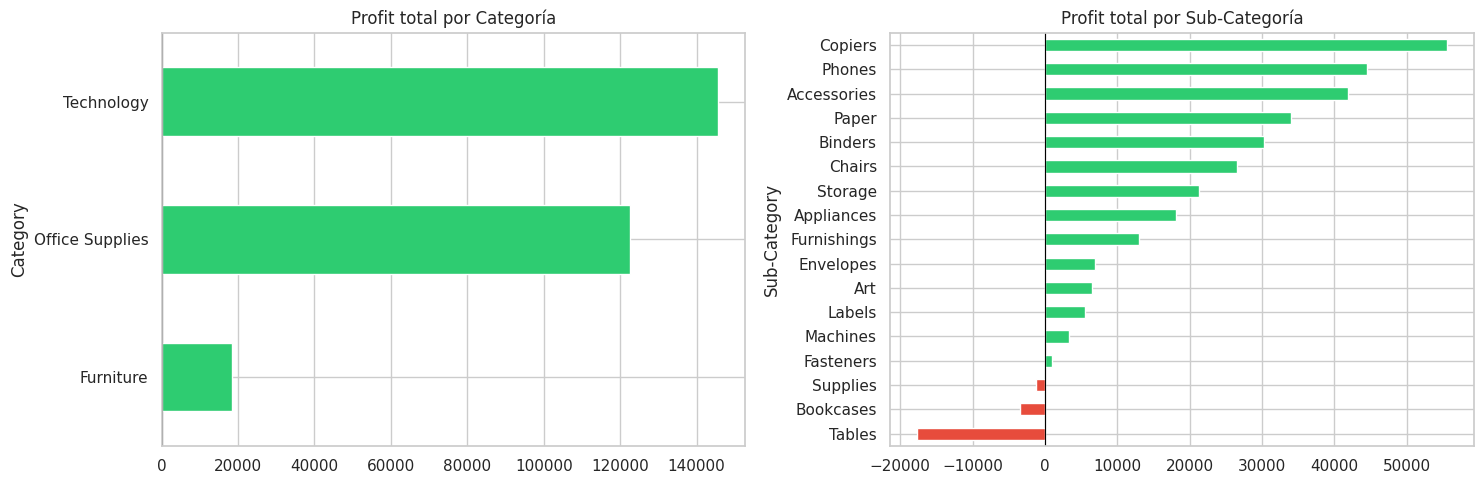

In [ ]:
# Profit por categoría y sub-categoría (insights de negocio)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Por categoría
profit_cat = df.groupby('Category')['Profit'].sum().sort_values()
colores_cat = ['#e74c3c' if v < 0 else '#2ecc71' for v in profit_cat.values]
profit_cat.plot(kind='barh', ax=axes[0], color=colores_cat)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Profit total por Categoría')

# Por sub-categoría (top peores y mejores)
profit_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colores_sub = ['#e74c3c' if v < 0 else '#2ecc71' for v in profit_sub.values]
profit_sub.plot(kind='barh', ax=axes[1], color=colores_sub)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit total por Sub-Categoría')

plt.tight_layout()
plt.show()

---
## PASO 11 — Feature Engineering

**¿Qué hacemos?** Crear nuevas variables a partir de las existentes que aporten información adicional al modelo.

**Tipos de feature engineering:**

| Tipo | Ejemplo | Cuándo |
|---|---|---|
| Diferencia de fechas | `days_to_ship = Ship Date - Order Date` | Siempre que hay dos fechas |
| Extracción de fecha | `mes`, `año`, `día de la semana` | Si hay estacionalidad |
| Ratio | `revenue_per_unit = Sales / Quantity` | Para normalizar por volumen |
| Flag binaria | `has_discount = (Discount > 0)` | Para destacar una condición |
| Agregados | `total_sales_by_customer` | Añadir contexto de nivel superior |

**⚠️ Regla de oro:** Nunca uses una variable derivada del **target** como feature. Es data leakage.

In [ ]:
#Antes de empezar el Feature Engineering miramos la variable objetivos
# Target de clasificación
df['is_profitable'] = (df['Profit'] > 0).astype(int)

#No hacemos future eng. con la variable target profit para no influir en el peso de las variables

In [ ]:
# Feature Engineering sobre Superstore

# 1. Días entre pedido y envío
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# 2. Extracción de fecha
df['order_year']  = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['order_quarter'] = df['Order Date'].dt.quarter

# 3. Ratio: ingreso por unidad
df['revenue_per_unit'] = df['Sales'] / df['Quantity']

# 4. Flag: ¿tiene descuento?
df['has_discount'] = (df['Discount'] > 0).astype(int)

# Verificación
nuevas_cols = ['days_to_ship', 'order_year', 'order_month', 'order_quarter',
               'revenue_per_unit', 'has_discount', 'is_profitable']
print('=== NUEVAS FEATURES ===')
print(df[nuevas_cols].describe().round(2))
print()

# Validación: ¿hay días_to_ship negativos? (indicaría error en fechas)
neg = (df['days_to_ship'] < 0).sum()
print(f'Pedidos con days_to_ship < 0: {neg}  (debería ser 0)')

=== NUEVAS FEATURES ===
       days_to_ship  order_year  order_month  order_quarter  revenue_per_unit  \
count       9994.00     9994.00      9994.00        9994.00           9994.00   
mean           3.96     2015.72         7.81           2.88             60.92   
std            1.75        1.12         3.28           1.06            142.93   
min            0.00     2014.00         1.00           1.00              0.34   
25%            3.00     2015.00         5.00           2.00              5.47   
50%            4.00     2016.00         9.00           3.00             16.27   
75%            5.00     2017.00        11.00           4.00             63.94   
max            7.00     2017.00        12.00           4.00           3773.08   

       has_discount  is_profitable  
count       9994.00        9994.00  
mean           0.52           0.81  
std            0.50           0.40  
min            0.00           0.00  
25%            0.00           1.00  
50%            1.00     

---
## PASO 12 — Encoding (codificación de categóricas)

**¿Por qué?** Los modelos de ML necesitan números. Las variables de texto hay que convertirlas.

**Dos técnicas principales:**

| Técnica | Cuándo usarla | Ejemplo |
|---|---|---|
| **Label Encoding** | Modelos de árbol (RF, XGBoost, Decision Tree) | `Furniture → 0`, `Office → 1`, `Tech → 2` |
| **One-Hot Encoding** | Regresión lineal, SVM, KNN | Crea una columna por cada categoría (0/1) |

**¿Por qué Label Encoding funciona en árboles pero no en lineales?**
- Un árbol parte por umbrales: `if Category_enc <= 1` → no le importa el orden numérico
- Un modelo lineal interpreta que `2 > 1 > 0` → cree que Technology es el doble que Office Supplies

In [ ]:
from sklearn.preprocessing import LabelEncoder

# OPCIÓN A: LABEL ENCODING (para modelos de árbol)
cols_a_encodear = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

le = LabelEncoder()
df_le = df.copy()

for col in cols_a_encodear:
    df_le[col + '_enc'] = le.fit_transform(df[col])

print('=== LABEL ENCODING ===')
print('Ejemplo en Category:')
print(df_le[['Category', 'Category_enc']].drop_duplicates().sort_values('Category_enc').to_string())
print()

# OPCIÓN B: ONE-HOT ENCODING (para modelos lineales)
df_ohe = pd.get_dummies(df[cols_a_encodear], drop_first=True, dtype=int)
print(f'=== ONE-HOT ENCODING ===')
print(f'Columnas generadas: {df_ohe.shape[1]}')
print(df_ohe.columns.tolist()[:8], '...')

=== LABEL ENCODING ===
Ejemplo en Category:
          Category  Category_enc
0        Furniture             0
2  Office Supplies             1
7       Technology             2

=== ONE-HOT ENCODING ===
Columnas generadas: 26
['Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office', 'Region_East', 'Region_South', 'Region_West'] ...


---
## PASO 13 — Escalado de variables numéricas

**¿Por qué?** Si `Sales` va de 0 a 22.000 y `Discount` va de 0 a 0.8, los modelos basados en distancias o en gradiente darán más peso a Sales automáticamente.

**¿Cuándo es necesario el escalado?**

| Modelo | ¿Necesita escalado? |
|---|---|
| Regresión Logística | ✅ Sí |
| SVM | ✅ Sí |
| KNN | ✅ Sí |
| Redes neuronales | ✅ Sí |
| Decision Tree | ❌ No |
| Random Forest | ❌ No |
| XGBoost | ❌ No |

**Tres escaladores principales:**
| Escalador | Resultado | Cuándo |
|---|---|---|
| `StandardScaler` | Media=0, Std=1 | Uso general, asume distribución aproximadamente normal |
| `MinMaxScaler` | Rango [0, 1] | Cuando necesitas valores acotados |
| `RobustScaler` | Usa mediana e IQR | Cuando hay muchos outliers |

**⚠️ Regla crítica:** Ajustar el scaler SOLO con los datos de entrenamiento (`fit_transform`), luego aplicar a test (`transform`). Nunca hacer `fit_transform` en el test.

StandardScaler — el más usado
Los valores quedan centrados en 0, positivos si están por encima de la media, negativos si están por debajo.

MinMaxScaler — cuando necesitas valores entre 0 y 1
El problema es que si un outlier extremo es el máximo, comprime todos los demás valores en un rango muy pequeño.

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split

# Preparamos un ejemplo con el conjunto de features para clasificación
features_ejemplo = ['Sales', 'Quantity', 'Discount', 'days_to_ship',
                    'revenue_per_unit', 'Category_enc', 'Sub-Category_enc']

X = df_le[features_ejemplo]
y = df_le['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print()

# Comparativa de los tres escaladores sobre Sales
escaladores = {
    'Original'       : X_train['Sales'],
    'StandardScaler' : StandardScaler().fit_transform(X_train[['Sales']]).flatten(),
    'MinMaxScaler'   : MinMaxScaler().fit_transform(X_train[['Sales']]).flatten(),
    'RobustScaler'   : RobustScaler().fit_transform(X_train[['Sales']]).flatten(),
}

comp = pd.DataFrame({k: pd.Series(v) for k, v in escaladores.items()})
print('Estadísticas de Sales con cada escalador:')
print(comp.describe().round(3))

Train: (7995, 7)  |  Test: (1999, 7)

Estadísticas de Sales con cada escalador:
        Original  StandardScaler  MinMaxScaler  RobustScaler
count   7995.000        7995.000      7995.000      7995.000
mean     227.610           0.000         0.010         0.910
std      636.220           1.000         0.028         3.351
min        0.556          -0.357         0.000        -0.286
25%       17.145          -0.331         0.001        -0.198
50%       54.816          -0.272         0.002         0.000
75%      207.000          -0.032         0.009         0.802
max    22638.480          35.227         1.000       118.952


In [ ]:
# Aplicación correcta del escalado: fit en train, transform en ambos

scaler = StandardScaler()

# ✅ CORRECTO
X_train_scaled = scaler.fit_transform(X_train)   # aprende la media y std del train
X_test_scaled  = scaler.transform(X_test)         # aplica los mismos parámetros al test

# ❌ INCORRECTO (nunca hacer esto)
# X_test_scaled = scaler.fit_transform(X_test)   # esto contaminaría con información del test

print('Train escalado — media y std de cada feature:')
pd.DataFrame(X_train_scaled, columns=features_ejemplo).describe().loc[['mean','std']].round(3)

Train escalado — media y std de cada feature:


,Sales,Quantity,Discount,days_to_ship,revenue_per_unit,Category_enc,Sub-Category_enc
mean,0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


---
## PASO 14 — Checklist final del EDA

Antes de pasar a entrenar modelos, verifica que has completado todos los pasos:

In [ ]:
print('=== CHECKLIST EDA — ESTADO ACTUAL DEL DATASET ===')
print()

checks = [
    ('✅', 'Dataset cargado correctamente',                    f'{df.shape[0]:,} filas × {df.shape[1]} columnas'),
    ('✅', 'Tipos de variables verificados y corregidos',      'Order Date y Ship Date como datetime'),
    ('✅', 'Nulos identificados',                              f'{df.isnull().sum().sum()} nulos en total'),
    ('✅', 'Duplicados identificados',                         f'{df.duplicated().sum()} filas duplicadas'),
    ('✅', 'Outliers analizados',                              'Conservados (valores legítimos de negocio)'),
    ('✅', 'Distribuciones exploradas',                        'Sales y Profit son asimétricas (+)'),
    ('✅', 'Categóricas analizadas',                           f'{len(cols_a_encodear)} columnas con cardinalidad moderada'),
    ('✅', 'Correlaciones calculadas',                         'Discount (-) y Sales (+) correlacionan con Profit'),
    ('✅', 'Target analizado',                                 f'{(df["is_profitable"]==1).mean()*100:.1f}% rentables'),
    ('✅', 'Feature engineering realizado',                    '7 nuevas variables creadas'),
    ('✅', 'Encoding aplicado',                                'Label Encoding para 5 categóricas'),
    ('✅', 'Escalado preparado',                               'StandardScaler fit en train, transform en test'),
]

for icono, paso, detalle in checks:
    print(f'  {icono}  {paso:<45}  → {detalle}')

print()
print('=== DATASET LISTO PARA MODELADO ===')
print(f'Features disponibles: {features_ejemplo}')
print(f'Target clasificación: is_profitable  (0/1)')
print(f'Target regresión    : Profit  (numérico continuo)')

=== CHECKLIST EDA — ESTADO ACTUAL DEL DATASET ===

  ✅  Dataset cargado correctamente                  → 9,994 filas × 28 columnas
  ✅  Tipos de variables verificados y corregidos    → Order Date y Ship Date como datetime
  ✅  Nulos identificados                            → 0 nulos en total
  ✅  Duplicados identificados                       → 0 filas duplicadas
  ✅  Outliers analizados                            → Conservados (valores legítimos de negocio)
  ✅  Distribuciones exploradas                      → Sales y Profit son asimétricas (+)
  ✅  Categóricas analizadas                         → 5 columnas con cardinalidad moderada
  ✅  Correlaciones calculadas                       → Discount (-) y Sales (+) correlacionan con Profit
  ✅  Target analizado                               → 80.6% rentables
  ✅  Feature engineering realizado                  → 7 nuevas variables creadas
  ✅  Encoding aplicado                              → Label Encoding para 5 categóricas
  ✅  Escalado 

---
## 📋 Resumen de decisiones tomadas en este EDA

| Paso | Lo que encontramos | Decisión tomada |
|---|---|---|
| Tipos | Order Date como `object` | Convertir a `datetime` con `format='%m/%d/%Y'` |
| Tipos | Postal Code como `int64` | Convertir a `string` con `zfill(5)` |
| Nulos | 0 nulos | Sin acción necesaria |
| Duplicados | 0 duplicados | Sin acción necesaria |
| Outliers | Sales y Profit con outliers extremos | **Conservar** — son valores reales de negocio |
| Distribución | Sales y Profit muy asimétricas | Usar modelos de árbol (robustos ante outliers) |
| Categóricas | Country constante (solo USA) | **Eliminar** — no aporta varianza |
| Correlación | Discount fuerte correlación negativa con Profit | Feature clave para el modelo |
| Target | 81% rentables / 19% no rentables | Desbalanceo moderado → usar `stratify` y métricas F1/AUC |
| Feature Eng. | Crear `days_to_ship`, `revenue_per_unit`, `has_discount` | Variables que pueden aportar señal |
| Encoding | 5 categóricas con cardinalidad 2-17 | Label Encoding (para modelos de árbol) |
| Escalado | Solo necesario para modelos lineales/KNN | StandardScaler solo para esos modelos |

---

### 💡 Recordatorio final

```
EDA no es un trámite. Es donde entiendes tus datos.
Un modelo entrenado sobre datos mal preparados dará resultados malos
independientemente de lo sofisticado que sea el algoritmo.

"Garbage in, garbage out."
```